In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
### The working directory is C:\...\ml-classification-project-1\notebooks. So we need to add  ".." at the front, meaning one level up, as "data" file is not within "notebook" file.
df = pd.read_csv("../data/credit_card_fraud_2026.csv")

In [4]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [5]:
df.shape

(20000, 26)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  str    
 3   card_type                     20000 non-null  str    
 4   auth_method                   20000 non-null  str    
 5   channel                       20000 non-null  str    
 6   device_type                   20000 non-null  str    
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  account_bala

In [7]:
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.98305
1    0.01695
Name: proportion, dtype: float64

In [8]:
df.head(n=5)

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [9]:
df.isna()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull() ## This is the same as isna()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum().sort_values(ascending=False)

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

In [99]:
df.duplicated().sum()

np.int64(0)

# Numerical Variables

In [16]:
df.groupby("is_fraud")["amount_usd"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,19661.0,131.582739,254.241020,1.00,26.21,57.35,130.88,6872.69
1,339.0,181.249853,380.460485,4.09,28.62,69.77,165.32,3356.46


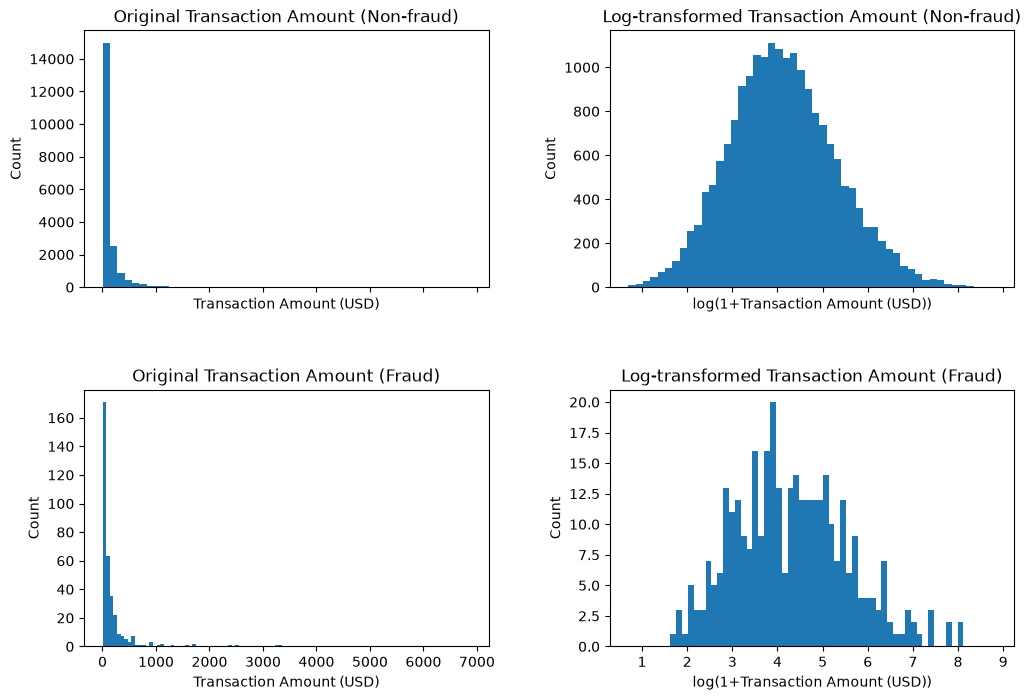

In [43]:
## Visualizations

### Raw distribution
raw0 = df.loc[df["is_fraud"] == 0, "amount_usd"]
raw1 = df.loc[df["is_fraud"] == 1, "amount_usd"]

### log-transformed distribution
logtrans0 = np.log1p(raw0)
logtrans1 = np.log1p(raw1)

### Draw graphs
fig, axes = plt.subplots(2,2, figsize=(12,8), sharex = "col")
axes[0, 0].hist(raw0, bins = 50)
axes[0, 0].set_title("Original Transaction Amount (Non-fraud)")
axes[0, 0].set_xlabel("Transaction Amount (USD)")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(logtrans0, bins = 50)
axes[0, 1].set_title("Log-transformed Transaction Amount (Non-fraud)")
axes[0, 1].set_xlabel("log(1+Transaction Amount (USD))")
axes[0, 1].set_ylabel("Count")

axes[1, 0].hist(raw1, bins = 50)
axes[1, 0].set_title("Original Transaction Amount (Fraud)")
axes[1, 0].set_xlabel("Transaction Amount (USD)")
axes[1, 0].set_ylabel("Count")


axes[1, 1].hist(logtrans1, bins = 50)
axes[1, 1].set_title("Log-transformed Transaction Amount (Fraud)")
axes[1, 1].set_xlabel("log(1+Transaction Amount (USD))")
axes[1, 1].set_ylabel("Count")

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()



In [59]:
## Look at columns based on dtype
numeric_cols = df.select_dtypes(include = "number")
categorical_cols = df.select_dtypes(include = ["object", "category"])

print(numeric_cols.columns)
print(categorical_cols.columns)

Index(['transaction_id', 'amount_usd', 'hours_since_last_txn',
       'txn_count_last_24h', 'distance_from_home_km', 'card_age_months',
       'customer_age', 'account_balance_usd', 'cvv_retry_count',
       'velocity_score', 'time_of_day_hour', 'day_of_week',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='str')
Index(['merchant_category', 'card_type', 'auth_method', 'channel',
       'device_type'],
      dtype='str')


C:\Users\Weiyue Chen\AppData\Local\Temp\ipykernel_4520\2572792571.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include = ["object", "category"])


In [66]:
numeric_cols.head(5)

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,13.54,2,22.35,39,25,1080.71,0,0.1,18,3,42.3,0,0
1,2,4.75,0.71,2,35.28,47,33,4463.72,0,25.8,12,4,28.3,0,0
2,3,77.18,0.35,5,9.82,51,59,366.25,0,42.3,5,0,24.7,1,0
3,4,1.69,3.42,6,19.72,48,28,1345.29,0,28.9,22,6,56.2,1,0
4,5,261.68,2.43,2,17.68,43,36,4192.59,0,3.9,2,4,32.7,0,0


In [70]:
## Look at 'cvv_retry_count'
df["cvv_retry_count"].groupby(df["is_fraud"]).value_counts().sort_index()


is_fraud  cvv_retry_count
0         0                  16505
          1                   2930
          2                    213
          3                     13
1         0                    153
          1                    143
          2                     41
          3                      2
Name: count, dtype: int64

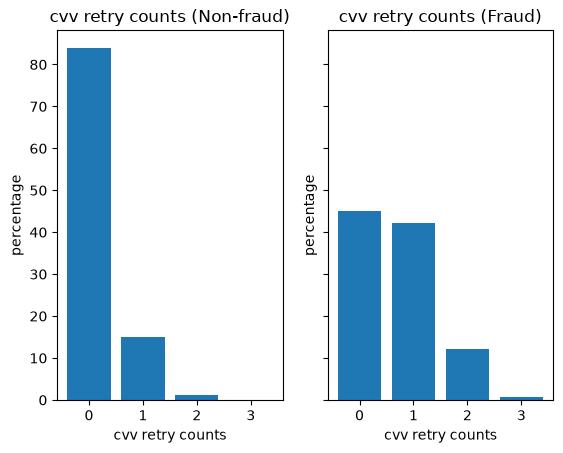

In [91]:
prop0 = df[df["is_fraud"] == 0]["cvv_retry_count"].value_counts(normalize = True).sort_index()*100
prop1 = df[df["is_fraud"] == 1]["cvv_retry_count"].value_counts(normalize = True).sort_index()*100

fig, axes = plt.subplots(1, 2, sharey = True)
axes[0].bar(prop0.index, prop0.values)
axes[0].set_xlabel("cvv retry counts")
axes[0].set_ylabel("percentage")
axes[0].set_title("cvv retry counts (Non-fraud)")

axes[1].bar(prop1.index, prop1.values)
axes[1].set_xlabel("cvv retry counts")
axes[1].set_ylabel("percentage")
axes[1].set_title("cvv retry counts (Fraud)")
plt.show()

In [106]:
def visualize_hist(col_name, dataframe, bin_num):

    ### Raw distribution
    raw0 = df.loc[df["is_fraud"] == 0, col_name]
    raw1 = df.loc[df["is_fraud"] == 1, col_name]

    ### Draw graphs
    fig, axes = plt.subplots(1,2, figsize=(12,8), sharex = "col")
    axes[0].hist(raw0, bins = bin_num)
    axes[0].set_title(f"Distribution of {col_name} for Non-fraud")
    axes[0].set_xlabel(col_name)
    axes[0].set_ylabel("Count")

    axes[1].hist(raw1, bins = bin_num)
    axes[1].set_title(f"Distribution of {col_name} for Fraud")
    axes[1].set_xlabel(col_name)
    axes[1].set_ylabel("Count")


    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

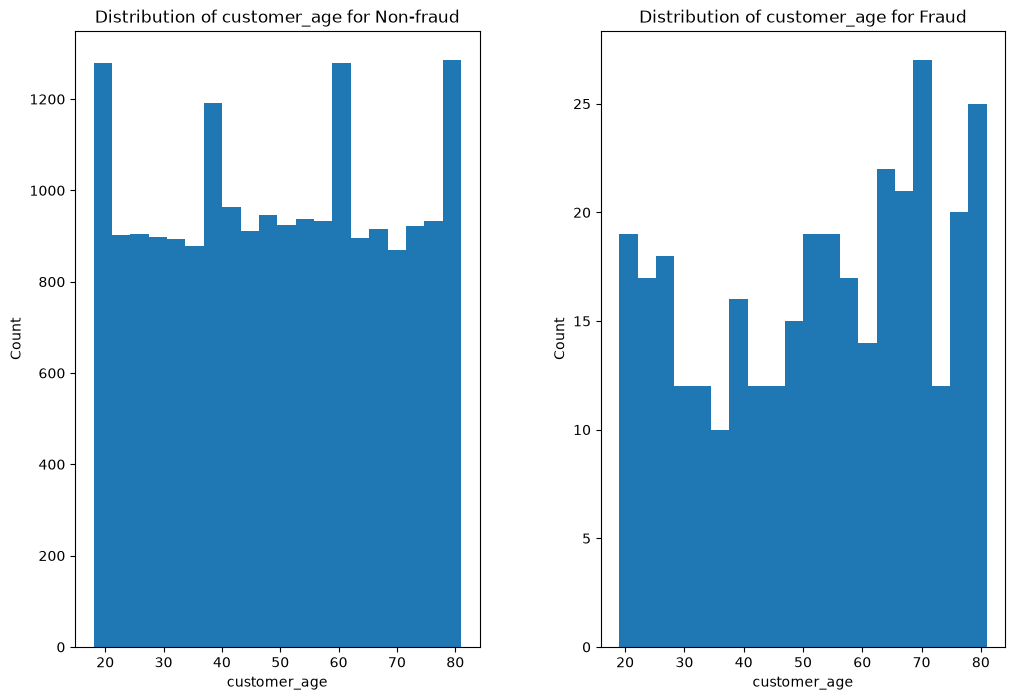

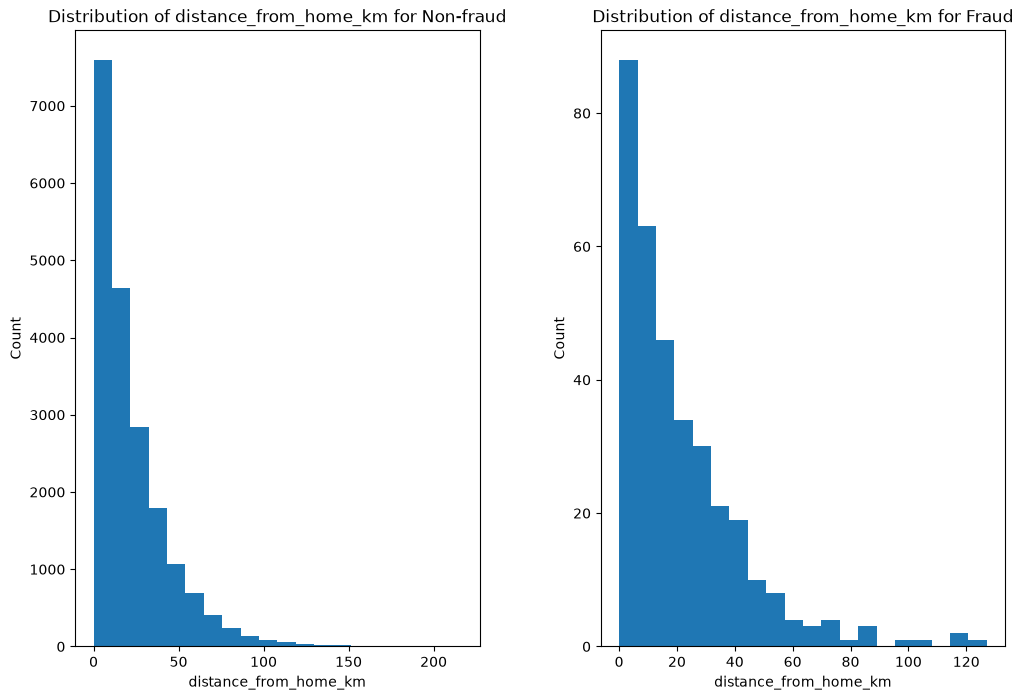

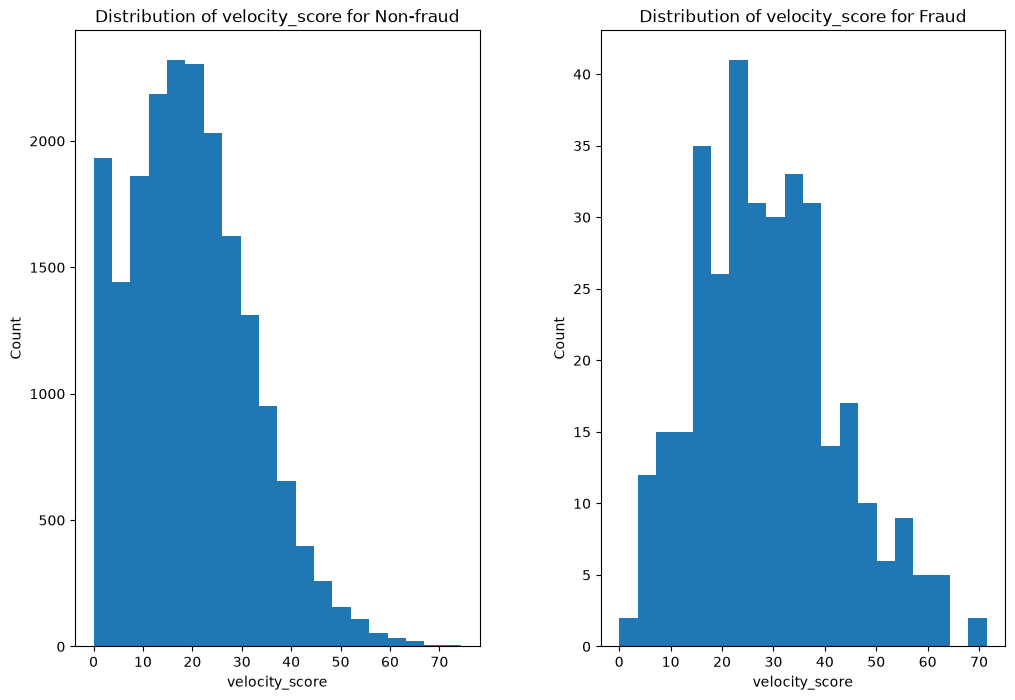

In [108]:
visualize_hist("customer_age", df, 20)
visualize_hist("distance_from_home_km", df, 20)
visualize_hist("velocity_score", df, 20)

In [164]:
df["velocity_score"].groupby(df["is_fraud"]).describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,19661.0,19.649814,12.282501,0.0,10.60,18.7,27.5,74.4
1,339.0,28.966667,13.709075,0.0,18.45,27.7,37.7,71.5


# Categorical Variables

In [63]:
categorical_cols.describe()

,merchant_category,card_type,auth_method,channel,device_type
count,20000,20000,20000,20000,20000
unique,12,5,5,5,8
top,Online Retail,Visa,3D Secure,Online,Android Phone
freq,3416,8417,5554,6810,5503


In [113]:
df["device_type"].value_counts()

device_type
Android Phone    5503
iPhone           4179
POS Terminal     3162
Windows PC       2623
Mac              1359
Tablet           1161
Smart Watch      1008
ATM Machine      1005
Name: count, dtype: int64

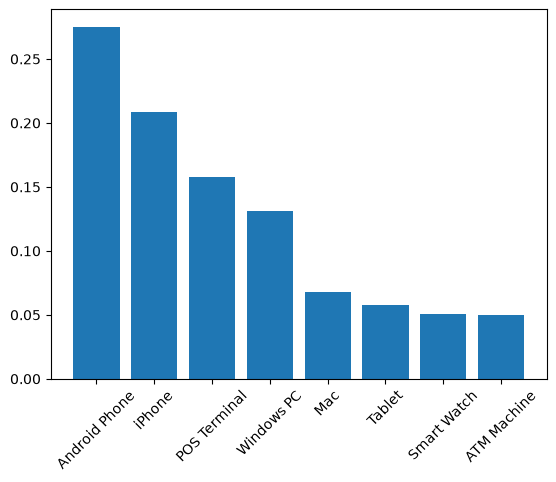

In [126]:
a=df["device_type"].value_counts(normalize=True)
plt.bar(a.index, a.values)
plt.xticks(rotation=45)
plt.show()

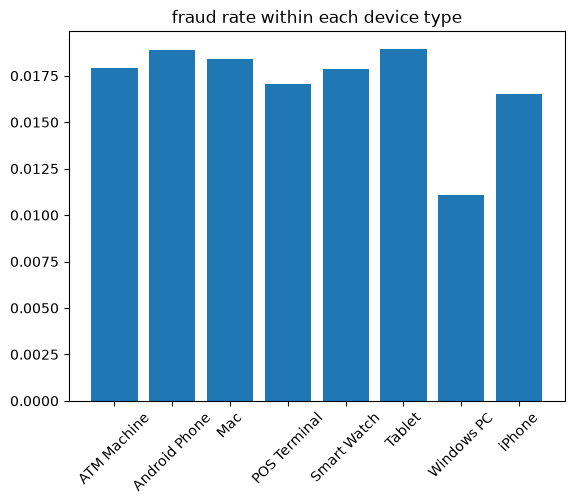

In [128]:
b=df.groupby("device_type")["is_fraud"].mean()
plt.bar(b.index, b.values)
plt.xticks(rotation=45)
plt.title("fraud rate within each device type")
plt.show()

In [129]:
device_summary = df.groupby("device_type")["is_fraud"].agg(
    count="count",
    fraud_count="sum",
    fraud_rate="mean"
)

device_summary

,count,fraud_count,fraud_rate
device_type,,,
ATM Machine,1005,18,0.017910
Android Phone,5503,104,0.018899
Mac,1359,25,0.018396
POS Terminal,3162,54,0.017078
Smart Watch,1008,18,0.017857
Tablet,1161,22,0.018949
Windows PC,2623,29,0.011056
iPhone,4179,69,0.016511


In [151]:
def visualize_cat(col_name, dataframe = df):
    a = df[col_name].value_counts(normalize = True)
    b = df.groupby(df[col_name])["is_fraud"].mean()
    b = b.reindex(a.index)
    fig, axes = plt.subplots(1, 2, figsize = (12,8))
# First subplot
    axes[0].bar(a.index, a.values)
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_title(f"Proportion of data within each {col_name}")

# Second subplot
    axes[1].bar(b.index, b.values)
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_title(f"Fraud rate within each {col_name}")

    plt.tight_layout()
    plt.show()

    return

In [135]:
categorical_cols

,merchant_category,card_type,auth_method,channel,device_type
0,Restaurants,Visa,OTP,Online,Android Phone
1,Online Retail,Mastercard,3D Secure,Online,Android Phone
2,Groceries,Mastercard,3D Secure,Online,Mac
3,Streaming,Visa,No Authentication,POS,Android Phone
4,Travel,Visa,3D Secure,In-App,iPhone
...,...,...,...,...,...
19995,Healthcare,Mastercard,OTP,POS,Android Phone
19996,Online Retail,Visa,OTP,POS,Android Phone
19997,Restaurants,Visa,3D Secure,In-App,Tablet
19998,Travel,Visa,3D Secure,Online,Android Phone


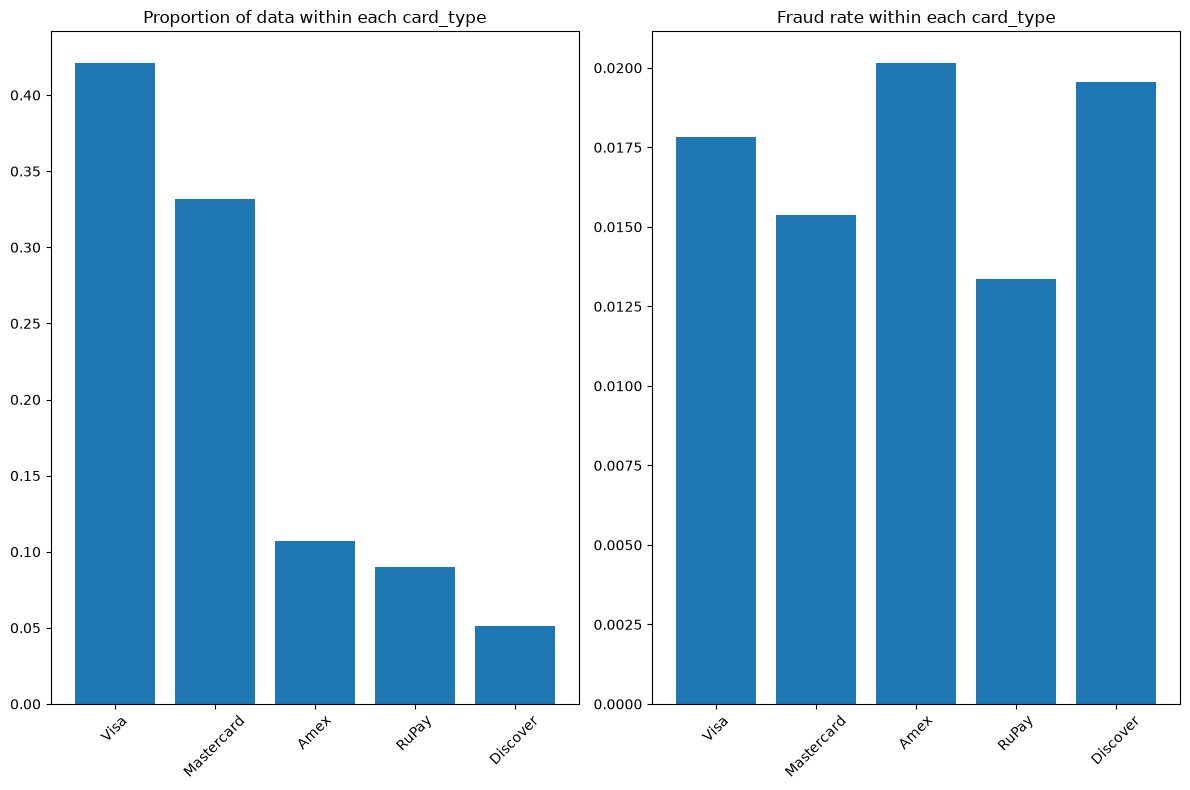

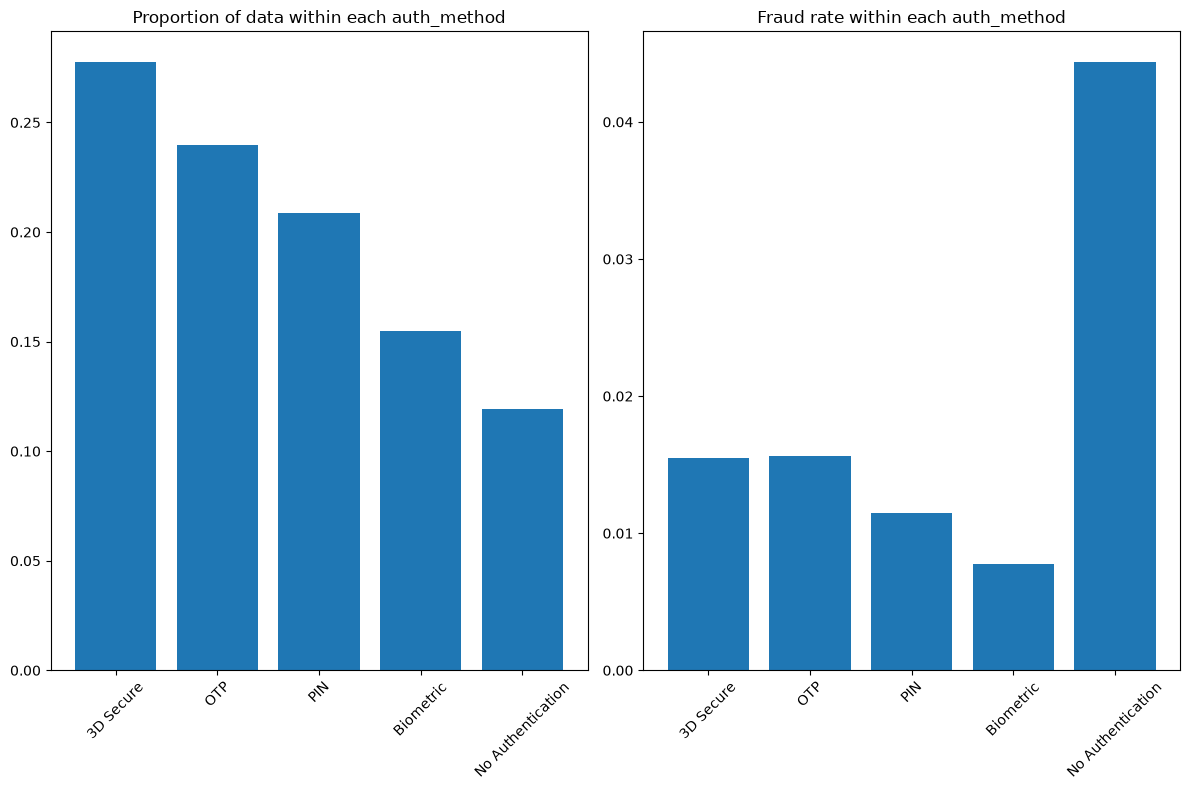

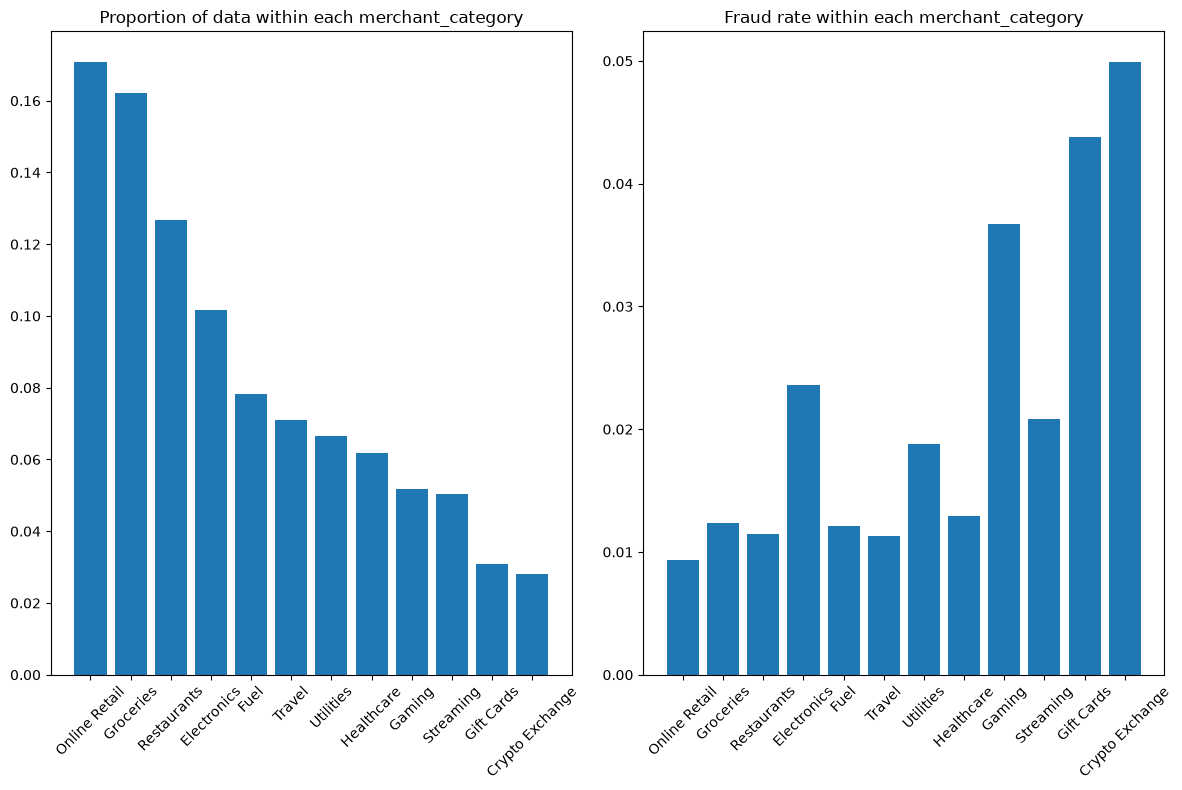

In [152]:
visualize_cat("card_type")
visualize_cat("auth_method")
visualize_cat("merchant_category")

# Feature relationships / Correlation

In [154]:
corr = df.select_dtypes(include = "number").corr() # look for linear associations with "is_fraud"
corr["is_fraud"].sort_values()
# Since is_fraud is 0/1, Pearson correlation can be used here to describe the linear relationship between numerical feature and fraud status.
# Later need to drop "transaction_id" since it's just an id.

time_of_day_hour        -0.030814
hours_since_last_txn    -0.028798
card_age_months         -0.012065
transaction_id          -0.005357
distance_from_home_km   -0.004292
account_balance_usd      0.004371
day_of_week              0.006071
customer_age             0.019543
prior_disputes           0.023903
amount_usd               0.024951
txn_count_last_24h       0.059866
velocity_score           0.097255
merchant_risk_score      0.107680
cvv_retry_count          0.155509
is_fraud                 1.000000
Name: is_fraud, dtype: float64

In [162]:
corr

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
transaction_id,1.000000,0.002441,-0.000601,-0.014184,0.001049,-0.003042,-0.005116,-0.011393,0.009363,-0.014253,-0.009452,-0.002361,-0.011370,0.009324,-0.005357
amount_usd,0.002441,1.000000,-0.004697,0.006365,-0.005460,0.012348,-0.010271,0.009512,-0.001462,0.014076,0.001197,0.005786,0.097103,0.003770,0.024951
hours_since_last_txn,-0.000601,-0.004697,1.000000,0.000508,-0.002970,-0.001885,-0.006366,0.007882,0.000617,-0.265509,0.002550,-0.006053,0.002697,0.000656,-0.028798
txn_count_last_24h,-0.014184,0.006365,0.000508,1.000000,0.006385,0.002571,0.001216,0.000606,0.005594,0.622395,0.005086,0.005323,0.006560,-0.004462,0.059866
distance_from_home_km,0.001049,-0.005460,-0.002970,0.006385,1.000000,0.004566,0.005347,0.002393,0.002889,-0.003026,0.011272,-0.002326,0.000702,-0.000854,-0.004292
card_age_months,-0.003042,0.012348,-0.001885,0.002571,0.004566,1.000000,0.005039,-0.008965,0.010276,0.009421,0.003870,-0.010024,0.006808,-0.000289,-0.012065
customer_age,-0.005116,-0.010271,-0.006366,0.001216,0.005347,0.005039,1.000000,0.004879,0.003449,0.002320,0.000728,0.001936,-0.000441,-0.010562,0.019543
account_balance_usd,-0.011393,0.009512,0.007882,0.000606,0.002393,-0.008965,0.004879,1.000000,0.000855,-0.002497,0.004680,0.004286,0.007838,0.003973,0.004371
cvv_retry_count,0.009363,-0.001462,0.000617,0.005594,0.002889,0.010276,0.003449,0.000855,1.000000,0.006100,-0.012054,0.000681,0.001961,0.000266,0.155509
velocity_score,-0.014253,0.014076,-0.265509,0.622395,-0.003026,0.009421,0.002320,-0.002497,0.006100,1.000000,0.000661,0.004900,0.006441,-0.002784,0.097255


<Axes: >

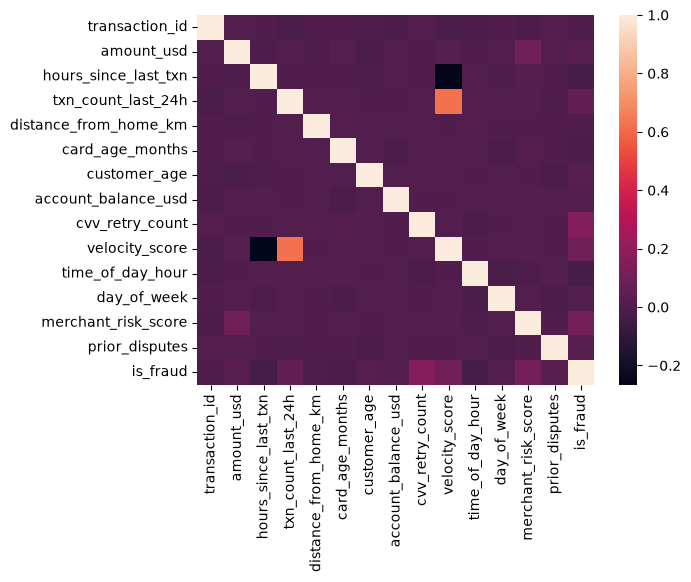

In [161]:
corr
sns.heatmap(corr)

# EDA summary

## Target Variable

First, the overall fraud rate was observed to be 1.695%, indicating a substantially imbalanced target variable. This implies that accuracy alone would not be an appropriate evaluation metric, since a model that always predicts a transaction as non-fraudulent could still achieve approximately 98% accuracy. Therefore, alternative evaluation metrics such as precision, recall, F1-score, and PR-AUC should be considered during model evaluation.


## Numerical Variables

### 1. `amount_usd`

Fraudulent transactions tend to have higher transaction amounts, with a higher mean, median, and upper quartile compared with non-fraudulent transactions. Fraudulent transaction amounts also show greater variability, as indicated by a larger standard deviation.

The distributions of transaction amounts for both groups are strongly right-skewed: their means are substantially higher than their medians, and their maximum values are much larger than their upper quartiles.

- The presence of extreme values should be investigated during preprocessing and modeling rather than automatically treated as observations that should be removed.
- Transaction amount may contain useful information for fraud prediction, although the difference between the two groups is not particularly large.

### 2. `cvv_retry_count`

Fraudulent transactions tend to have higher CVV retry counts. One- and two-retry transactions constitute a substantially higher proportion of fraudulent transactions. In particular, zero-retry transactions account for over 80% of non-fraudulent transactions but only approximately 45% of fraudulent transactions.

- This suggests that `cvv_retry_count` may be a useful predictor for fraud detection.

### 3. `customer_age` and `distance_from_home_km`

No substantial differences between fraudulent and non-fraudulent transactions were observed during the initial exploration of these two variables.

- However, the absence of obvious differences in their marginal distributions does not necessarily imply that these variables have no predictive value. Their relationships with fraud may be nonlinear or depend on interactions with other variables.

### 4. `velocity_score`

The distribution of `velocity_score` among fraudulent transactions appears less right-skewed than that of non-fraudulent transactions. The mean and quartiles are also higher among fraudulent transactions, while the two groups show relatively similar variability.

- This suggests that `velocity_score` may contain useful predictive information for fraud detection.


## Categorical Variables

### 1. `device_type`

Among the eight device types, Android phones and tablets show the highest observed fraud rates. However, the differences among most device types are relatively small. Transactions made through Windows PCs show a noticeably lower observed fraud rate (approximately 1.1%) compared with Android phones (approximately 1.89%), tablets (approximately 1.89%), and iPhones (approximately 1.65%).

- This suggests that `device_type` may have some association with fraud status, although the observed differences are relatively small.
- Overall, `device_type` appears to provide a weaker fraud signal than some of the other categorical variables examined.

### 2. `card_type`

The exploration of `card_type` did not reveal substantial differences in fraud rates across categories.

- This does not necessarily imply that `card_type` has no predictive value, as it may interact with other features.

### 3. `auth_method`

Transactions with no authentication show a substantially higher observed fraud rate than transactions using authentication methods. The fraud rate for transactions with no authentication is more than twice that observed for several authenticated transaction categories.

- This suggests that `auth_method`, particularly the absence of authentication, may provide useful information for identifying fraudulent transactions.
- However, this represents an association in the observed data and should not be interpreted as evidence that the authentication method itself causes or prevents fraud.

### 4. `merchant_category`

Fraud rates differ noticeably across merchant categories. In this dataset, transactions involving Crypto Exchanges, Gift Cards, Gaming, and Electronics show relatively high observed fraud rates, while categories such as Restaurants, Online Retail, and Fuel show lower observed fraud rates.

- This suggests that `merchant_category` may provide useful predictive information for fraud detection.
- However, differences in category sample sizes should be considered when interpreting these fraud rates.


## Correlations

### 1. Correlations Between Numerical Variables and the Target

The Pearson correlation analysis suggests that, among the numerical variables, `cvv_retry_count` and `merchant_risk_score` have relatively higher positive linear associations with `is_fraud`. `velocity_score` also shows some positive linear association with the target.

Most other numerical variables have correlations close to zero. However, a near-zero Pearson correlation only indicates the absence of a strong linear association and does not necessarily imply that a variable has no predictive value.

### 2. Correlations Between Numerical Predictors

`velocity_score` and `txn_count_last_24h` show a relatively strong positive correlation (r = 0.622), suggesting substantial overlapping information. One possible explanation is that transaction frequency contributes to the velocity score, although the exact construction of the score is unknown.

A relatively strong positive correlation was also observed between `merchant_risk_score` and `amount_usd`, suggesting potential overlapping information between these two variables. Several possible explanations may account for this relationship: higher-risk merchants may tend to be associated with larger transaction amounts; transaction amount may contribute to the construction of the merchant risk score; or both variables may be influenced by other underlying factors. These are possible explanations rather than conclusions that can be established from correlation alone.

These correlations should be considered during modeling, particularly for models that may be affected by multicollinearity.



